In [66]:

import numpy as np 
import pandas as pd

#all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/anupamacodtech/social-media/social_media_sleep_stress_productivity_11000.csv


In [67]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [68]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
df = pd.read_csv("/kaggle/input/datasets/anupamacodtech/social-media/social_media_sleep_stress_productivity_11000.csv")

df.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [70]:
#Data Understanding
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  11000 non-null  int64  
 1   age                      11000 non-null  int64  
 2   daily_screen_time_hours  11000 non-null  float64
 3   social_media_hours       11000 non-null  float64
 4   sleep_hours              11000 non-null  float64
 5   exercise_minutes         11000 non-null  int64  
 6   study_work_hours         11000 non-null  float64
 7   productivity_score       11000 non-null  float64
 8   stress_level             11000 non-null  object 
 9   platform                 11000 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 859.5+ KB


user_id                    0
age                        0
daily_screen_time_hours    0
social_media_hours         0
sleep_hours                0
exercise_minutes           0
study_work_hours           0
productivity_score         0
stress_level               0
platform                   0
dtype: int64

In [71]:
#Data Preprocessing
# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Convert categorical columns if present
df = pd.get_dummies(df, drop_first=True)

In [72]:
#Define Target & Features

#Assuming dataset contains:

#Productivity_Score (target)
X = df.drop("productivity_score", axis=1)
y = df["productivity_score"]

In [73]:
#Feature Selection
#import library
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=5)
X_new = selector.fit_transform(X, y)


selected_features = X.columns[selector.get_support()]
print("Top Features:", selected_features)

Top Features: Index(['user_id', 'age', 'sleep_hours', 'platform_LinkedIn',
       'platform_Twitter'],
      dtype='object')


In [74]:

# Import

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

In [75]:
# Import

# Model Training
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)



In [76]:
# Import

# Model Training
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [77]:
#Model Evaluation
def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE: 24.9511449067771
MSE: 834.8181057151758
R2 Score: 0.0010578088408598196

Random Forest
MAE: 26.02980922727273
MSE: 927.8271284537591
R2 Score: -0.11023665918275305


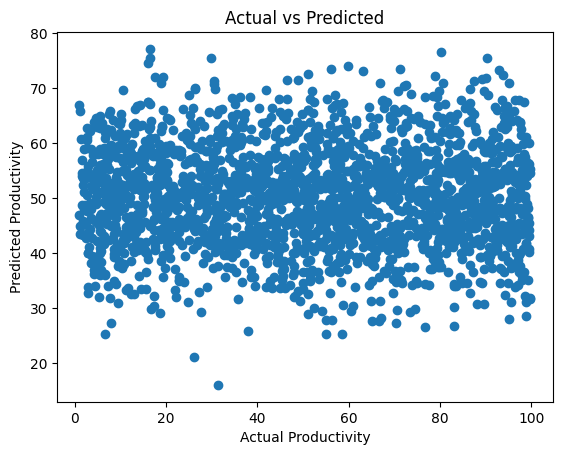

In [78]:
#import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted")
plt.show()

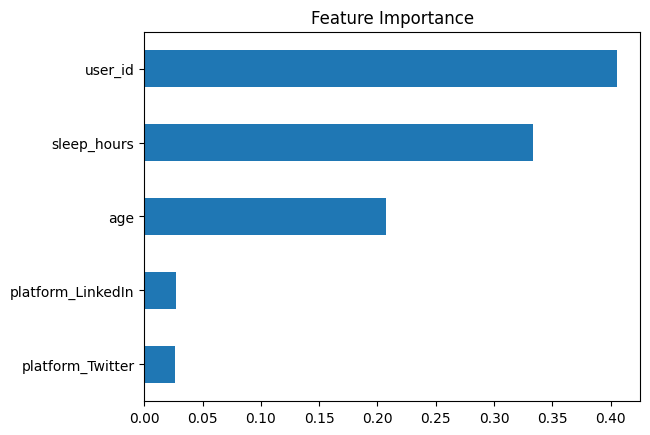

In [79]:


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#Feature Importance (Important for Marks)
importance = rf.feature_importances_
feat_importance = pd.Series(importance, index=selected_features)

feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()